<div style = "color:blue; font-size:25px">The goal of this project is to analyze factors affecting student's academic performance.

<div style = "color:blue; font-size:20px">Author: Kartika Nidhi<br>
Email: kartikanidhi@gmail.com<br>
LinkedIn: Kartika Nidhi
</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandas import Series, DataFrame


<div style = "color:blue; font-size:25px">1. Loading Dataset

In [2]:
data = pd.read_csv('/home/kartika/Datasets/student_data.csv')
data.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,6,6,5,6
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,16,18,19
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,14,15,15


<div style = "color:blue; font-size:25px">2. Basic Info about Dataset


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [13]:
data.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [14]:
data.duplicated().sum()

np.int64(0)

<div style = "color:blue; font-size:20px">No missing values and duplicate values.

<div>

<div>

<div style = "color:blue; font-size:25px">3. Filtering necessary columns

In [5]:
data.columns.unique()

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

<div style = "color:blue; font-size:20px">Out of 33 columns,(school, sex, age, address, famsize, Parent Status, Medu, Fedu, Mjob, Fjob, traveltime, studytime
, failures, internet, freetime, goout, health, absences, G3) will be focused columns for this analysis.

In [16]:
data = data[['school','sex','age','address','famsize','Pstatus','Medu','Fedu','Mjob','Fjob','traveltime','studytime','failures','internet',
'freetime','absences','G3']]
data.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,traveltime,studytime,failures,internet,freetime,absences,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,2,2,0,no,3,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,1,2,0,yes,3,4,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,1,2,3,yes,3,10,10
3,GP,F,15,U,GT3,T,4,2,health,services,1,3,0,yes,2,2,15
4,GP,F,16,U,GT3,T,3,3,other,other,1,2,0,no,3,4,10
5,GP,M,16,U,LE3,T,4,3,services,other,1,2,0,yes,4,10,15
6,GP,M,16,U,LE3,T,2,2,other,other,1,2,0,yes,4,0,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,2,2,0,no,1,6,6
8,GP,M,15,U,LE3,A,3,2,services,other,1,2,0,yes,2,0,19
9,GP,M,15,U,GT3,T,3,4,other,other,1,2,0,yes,5,0,15


<div>

<div>

<div style = "color:blue; font-size:25px">4. Univariate Analysis

<div style = "color:blue; font-size:25px">4.1 Sex Distribution

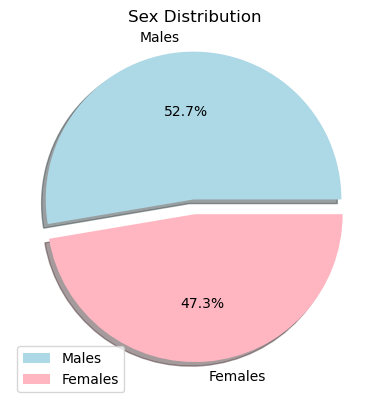

In [4]:
plt.pie(data['sex'].value_counts(), labels=['Males','Females'], explode = [0.1,0.0],colors = ['lightblue','lightpink'], autopct = "%1.1f%%", shadow = True)
plt.title("Sex Distribution")

plt.legend()
plt.show()

<div style = "color:blue; font-size:20px">The distribution is almost balanced, but males are slightly more represented.

<div style = "color:blue; font-size:25px">4.2 Age Distribution

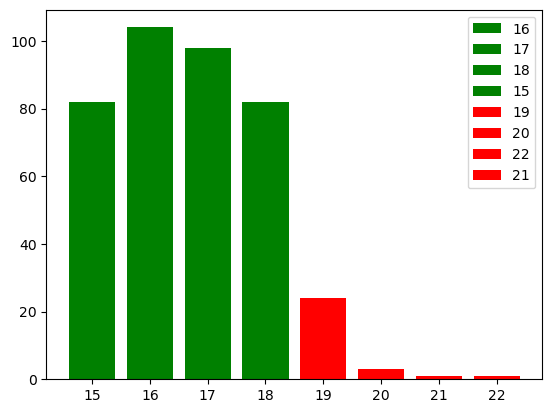

In [40]:
plt.bar(data['age'].value_counts().index, data['age'].value_counts().values,
 color = ['green','green','green','green','red','red','red','red'], label = data['age'].value_counts().index)

plt.legend()
plt.show()

<div style = "color:blue; font-size:20px"> The dataset is dominated by teenagers (15-18), with highest reprsentation, while individuals above 19 years
constitue the smallest proportion.

<div style = "color:blue; font-size:25px">4.3 Urban vs Rural

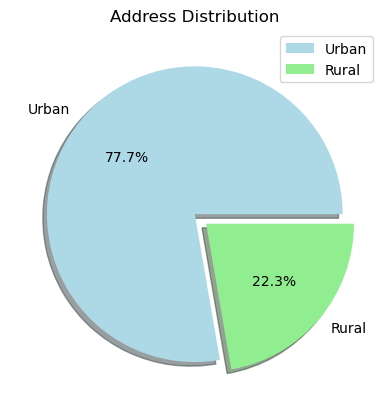

In [5]:
plt.pie(data.address.value_counts(), labels =['Urban','Rural'], explode = [0.0,0.1], colors = ['lightblue','lightgreen'], autopct = "%1.1f%%", shadow = True)

plt.title("Address Distribution")
plt.legend()
plt.show()

<div style = "color:blue; font-size:20px">The dataset is heavily dominated by urban students, while rural students account for much smaller proportion.

<div style = "color:blue; font-size:25px">4.4 Family Size Distribution

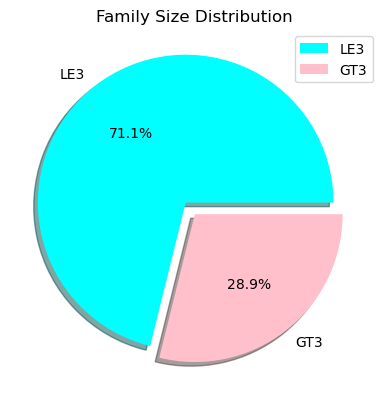

In [9]:
plt.pie(data.famsize.value_counts(), colors = ['cyan','pink'], labels = ['LE3','GT3'], explode = [0.1,0.0], autopct = "%1.1f%%", shadow = True)

plt.title("Family Size Distribution")
plt.legend()
plt.show()

<div style = "color:blue; font-size:20px">Most of the students, which is more than two/third of the students
belong to nuclear family, LE3 (Less than equal to three members). While, close to one/third of students belong to family with members greater than three.  

<div style = "color:blue; font-size:25px">4.5 Parents Status

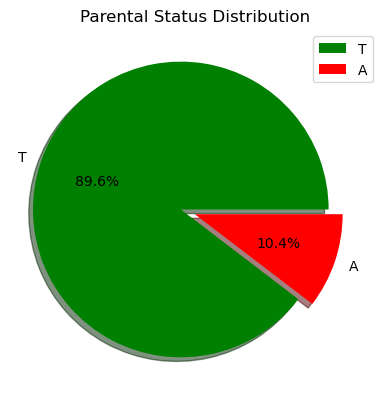

In [10]:
plt.pie(data.Pstatus.value_counts(), colors = ['green','red'], labels = ['T','A'], explode = [0.1,0.0], autopct = "%1.1f%%", shadow = True)

plt.title("Parental Status Distribution")
plt.legend()
plt.show()

<div style = "color:blue; font-size:20px">Most of the student's parents live together that is almost 90% of the total. While, few student's parents that is 10% of the total live apart.

<div style = "color:blue; font-size:25px">4.6 Parental Education Status

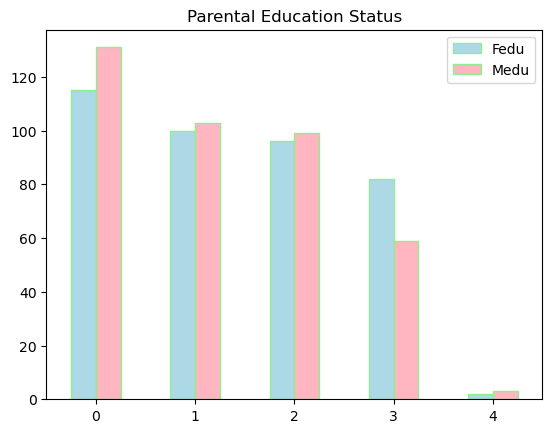

In [14]:
pedu = DataFrame({
    'Fedu':data.Fedu.value_counts().values,
    'Medu':data.Medu.value_counts().values
}, index = [0,1,2,3,4])


#To show bars one on top of each
# plt.bar(data.Fedu.value_counts().index, data.Fedu.value_counts().values, color = 'lightblue', label = 'Father Education', edgecolor = 'green')
# plt.bar(data.Medu.value_counts().index, data.Medu.value_counts().values, color = 'lightpink', label = 'Mother Education', edgecolor = 'green')

#To show bars side by side
pedu.plot(kind = 'bar', color = ['lightblue','lightpink'], edgecolor = 'lightgreen', label = ['Father Education','Mother Education'])

plt.title("Parental Education Status")
plt.xlabel = "Education Level"
plt.ylabel = 'Frequency'
plt.xticks(rotation = 0)
plt.legend()
plt.show()

<div style = "color:blue; font-size:20px">Education Level Description:
<ul>
<li>0 : None</li>
<li>1 : Primary(4th grade)</li>
<li>2 : 4th-9th grade</li>
<li>3 : Secondary</li>
<li>4 : Higher </li>
</ul>
</div>


<div style = "color:blue; font-size:20px">The chart indicates parents with generally low formal education. While mothers are slightly more likely to have primary-level schooling, fathers are notably more likely to reach a secondary education level. Overall, most the parents have education upto Secondary Level.</div>

<div style = "color:blue; font-size:25px">4.7 Parents Job Status

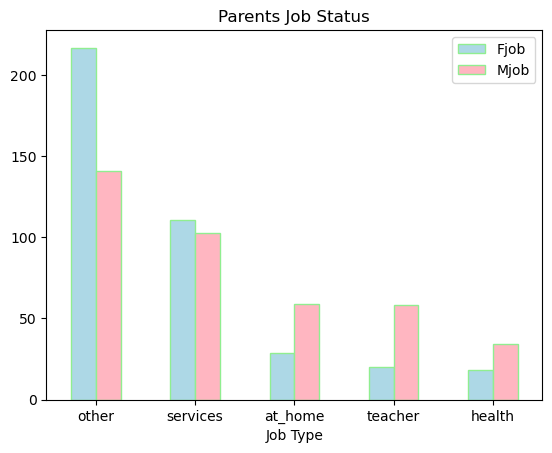

In [ ]:
job = DataFrame({
    'Fjob':data.Fjob.value_counts().values,
    'Mjob':data.Mjob.value_counts().values
}, index = data.Mjob.value_counts().index)

job.plot(kind = 'bar', color = ['lightblue','lightpink'], edgecolor = 'lightgreen', label = ["Father's Job","Mother's  Job"], xlabel = 'Job Type')

plt.title("Parents Job Status")
plt.ylabel = 'Frequency'
plt.xticks(rotation = 0)
plt.legend()
plt.show()

<div style = "color:blue; font-size:20px">The data shows that while a large portion of both parents work in "other" or "services" roles, there is a clear trend of mothers being more represented in teaching, healthcare, and stay-at-home positions, while fathers are more heavily concentrated in the "other" employment category.

<div style = "color:blue; font-size:25px">4.8 StudyTime

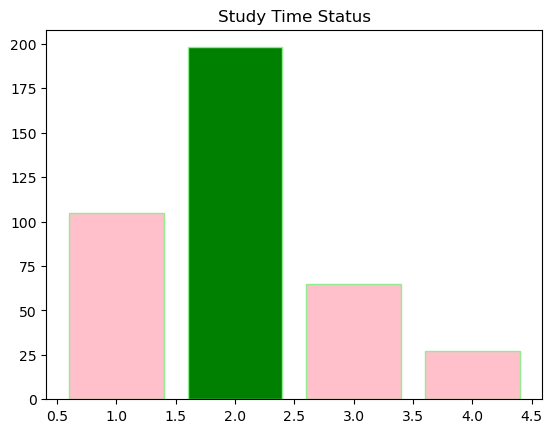

In [29]:
plt.bar(data.studytime.value_counts().index, data.studytime.value_counts().values, color = ['green','pink','pink','pink'], edgecolor = 'lightgreen')

plt.title("Study Time Status")
plt.xlabel = "Study Time in Hour"
plt.ylabel = "Nr of Students"
plt.show()

<div style = "color:blue; font-size:20px">2 Hours seems to be common study time for majority of students. While, 1 and 3 hours is common in moderate number of students. Only few number of students have 4 hours of study time.

<div style = "color:blue; font-size:25px"> 4.9 Internet Access Status

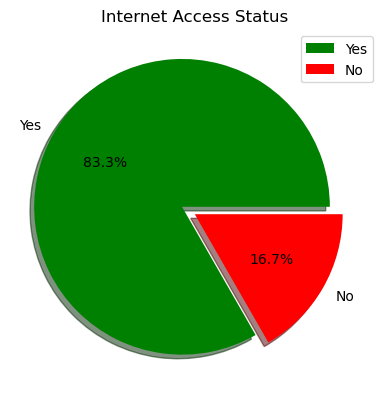

In [33]:
plt.pie(data.internet.value_counts(), colors = ['green','red'], labels = ['Yes','No'], explode = [0.1,0.0], autopct = "%1.1f%%", shadow = True)


plt.title("Internet Access Status")
plt.legend()
plt.show()

<div style = "color:blue; font-size:20px">Internet Access seems to be very common among students, with 83% students. While, nearly 17% students have no internet
access.

<div style = "color:blue; font-size:20px">4.10 Absences Status

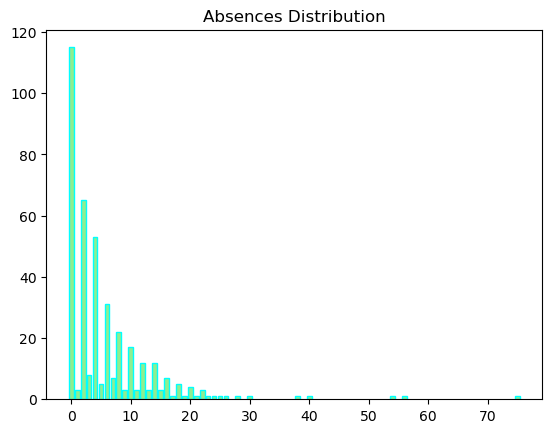

In [ ]:
plt.bar(data.absences.value_counts().index, data.absences.value_counts().values, color = 'lightgreen', edgecolor = 'cyan')

plt.title("Absences Distribution")
plt.xlabel = "Days"
plt.ylabel = "Freq of Students"
plt.show()


<div style = "color:blue; font-size:20px">The graph shows that most of the students are regular with absence of less than 10 days. While few students tends to irregular.

<div style = "color:blue; font-size:25px">4.11 G3(Final Score)[Target Variable]

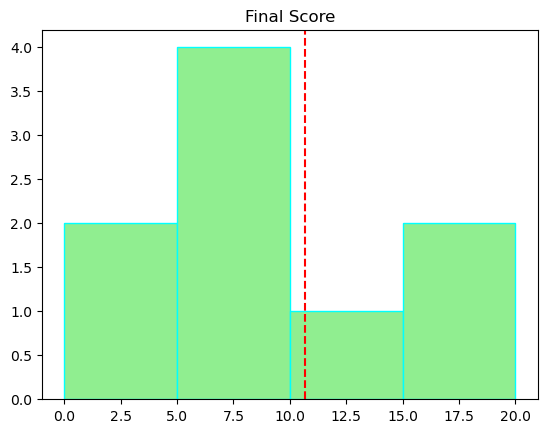

In [71]:
bins = np.arange(0,21,5)
plt.hist(data.G3.value_counts().values, bins= bins, color = 'lightgreen', edgecolor = 'cyan')


mean_score = ((data['G1']+data['G2']+data['G3'])/3).mean()
plt.axvline(mean_score, color = 'red', label = 'Mean Score', linestyle = '--')

plt.title("Final Score")
plt.xlabel = 'Scores'
plt.ylabel = 'Nr of Students'
plt.show()

<div style = "color:blue; font-size:20px">Most of the students scored between 5-10. Nr. of students scoring below 5 is same as students scoring above 15 that is nr. of least scoring and high scoring students are same.
Overall, students with different test score represent the data.

<div style = "color:blue; font-size:20px">Also, from the mean line, most of the students have scored below average.

<div>

<div>

<div>

<div style = "color:blue; font-size:25px">5. Bivariate Analysis